# BART ESPIRiT 감도맵(sensitivity map) 추출 — 단계별

`bart ecalib`이 멀티코일 k-space에서 **코일 감도맵**을 어떻게 뽑는지, 어떤 전처리/파라미터가
들어가는지 본다. 우리 `MakeDataset.py`가 이걸 호출해 `sens_map`을 저장한다.

**ESPIRiT 핵심 흐름**
1. k-space **중앙 ACS(calibration region)** 추출 (저주파, fully-sampled 영역)
2. ACS로 **calibration matrix** 구성 → **SVD** → 신호 부분공간(=GRAPPA 커널) 추출
3. 커널을 영상공간으로 보내 각 픽셀에서 **eigen-decomposition** → eigenvalue≈1인 고유벡터 = **감도맵**
4. eigenvalue가 낮은(물체 바깥) 곳은 맵을 **0으로 마스킹** → 그게 SENSE 영상의 검은 영역

In [3]:
import os, sys, glob
sys.path.insert(0, '/home/sonwonjun/research/MRRecon/code')
import numpy as np, h5py
import matplotlib.pyplot as plt
from MakeDataset import espirit_sens_maps                 # sets up BART (TOOLBOX_PATH/PATH)
sys.path.insert(0, os.path.join(os.environ['TOOLBOX_PATH'], 'python'))
from bart import bart
from mrrecon.data.transforms import sense_combine_np, rss_np

f = sorted(glob.glob('/mnt/d/research/MRRecon/knee/train/*.h5'))[0]
with h5py.File(f, 'r') as h:
    k = h['kspace'][:]                                    # (15,320,320) multi-coil k-space
print('input k-space', k.shape)

# BART layout: (x, y, z, coil) -> put coil last, add singleton
kb = k.transpose(1, 2, 0)[None]                           # (1,320,320,15)
def to_chw(smap):                                         # ecalib out (1,H,W,C[,M]) -> (C,H,W[,M])
    a = np.asarray(smap)
    return a.transpose(3, 1, 2, 0, *range(4, a.ndim)).squeeze(-1 if a.ndim == 4 else 0)

input k-space (15, 320, 320)


## 1. 기본 `ecalib` 실행 — 감도맵 + eigenvalue map

`bart ecalib -m1 -r24` : 맵 1개, calibration region 24. 두 번째 출력이 **eigenvalue map**으로,
값이 1에 가까우면 "유효한 감도", 낮으면 "물체 바깥 → 마스킹".

Done.
sens (15, 320, 320) | eigenvalue map (320, 320)


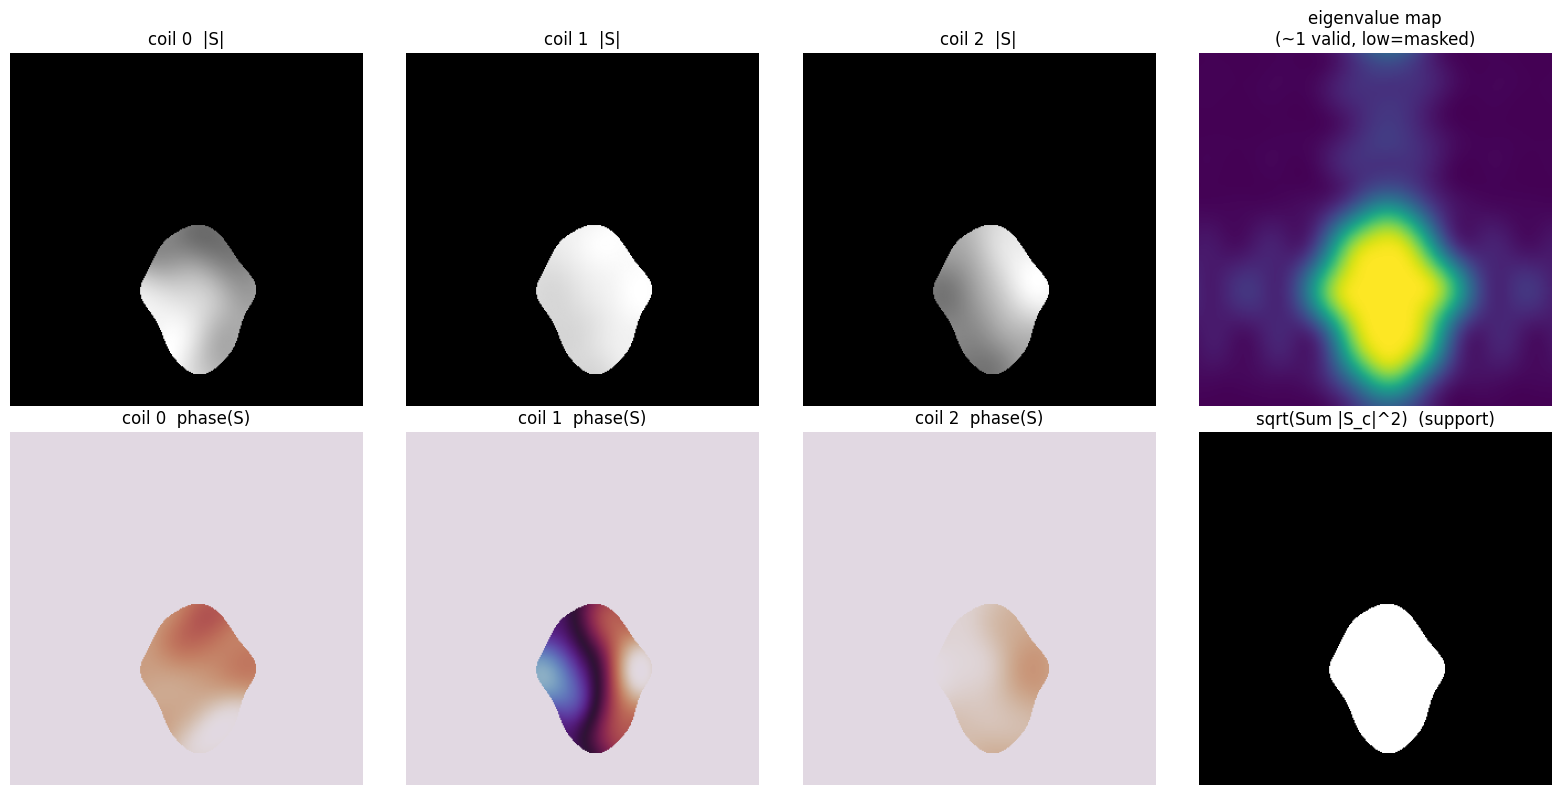

In [4]:
sens_b, evmap = bart(2, 'ecalib -d0 -m1 -r24', kb)       # sens (1,H,W,C), evmap (1,H,W)
maps = np.asarray(sens_b).transpose(3, 1, 2, 0).squeeze(-1)  # (15,320,320)
ev = np.abs(np.asarray(evmap).squeeze())                         # (320,320)
print('sens', maps.shape, '| eigenvalue map', ev.shape)

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
for j in range(3):
    ax[0, j].imshow(np.abs(maps[j]), cmap='gray'); ax[0, j].set_title(f'coil {j}  |S|'); ax[0, j].axis('off')
    ax[1, j].imshow(np.angle(maps[j]), cmap='twilight'); ax[1, j].set_title(f'coil {j}  phase(S)'); ax[1, j].axis('off')
ax[0, 3].imshow(ev, cmap='viridis'); ax[0, 3].set_title('eigenvalue map\n(~1 valid, low=masked)'); ax[0, 3].axis('off')
ax[1, 3].imshow(np.sqrt((np.abs(maps)**2).sum(0)), cmap='gray'); ax[1, 3].set_title('sqrt(Sum |S_c|^2)  (support)'); ax[1, 3].axis('off')
plt.tight_layout(); plt.show()

## 2. `-r` calibration region (ACS) 크기 효과

감도맵은 **중앙 저주파 ACS**로만 calibration한다. `-r`이 클수록 더 많은 중앙 라인을 써서
맵이 부드럽고 정확해지지만, prospective 언더샘플에선 ACS 폭을 넘으면 안 된다.

Done.
Done.
Done.
Done.


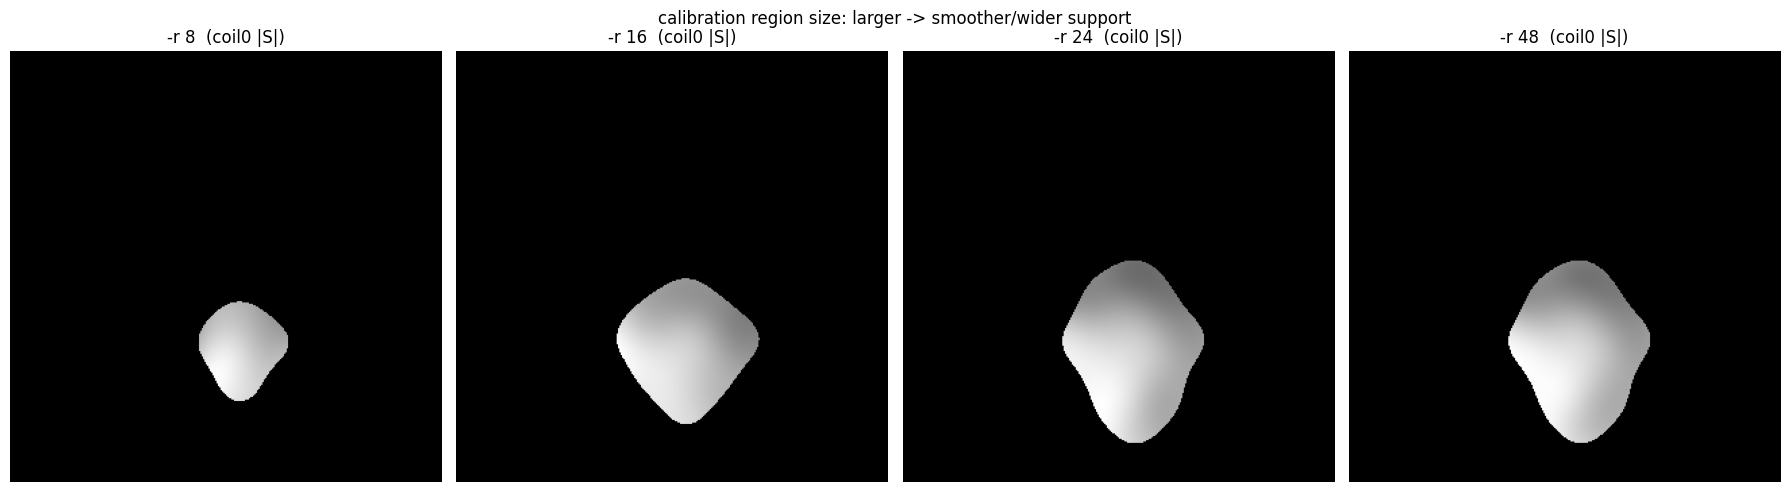

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
for j, r in enumerate([8, 16, 24, 48]):
    sm = bart(1, f'ecalib -d0 -m1 -r{r}', kb)
    m0 = np.abs(np.asarray(sm).transpose(3,1,2,0).squeeze(-1)[0])
    ax[j].imshow(m0, cmap='gray'); ax[j].set_title(f'-r {r}  (coil0 |S|)'); ax[j].axis('off')
plt.suptitle('calibration region size: larger -> smoother/wider support'); plt.tight_layout(); plt.show()

## 3. `-c` 마스킹(crop) 임계값 — **검은 영역의 원인**

`-c`는 eigenvalue가 이 값보다 작은 픽셀의 감도맵을 **0으로 자른다(마스킹)**. 그래서 물체 바깥이
0이 되어 SENSE 영상에서 검게 나온다. `-c 0`이면 마스킹 없이 어디서나 맵이 채워진다.

Done.
Done.
Done.


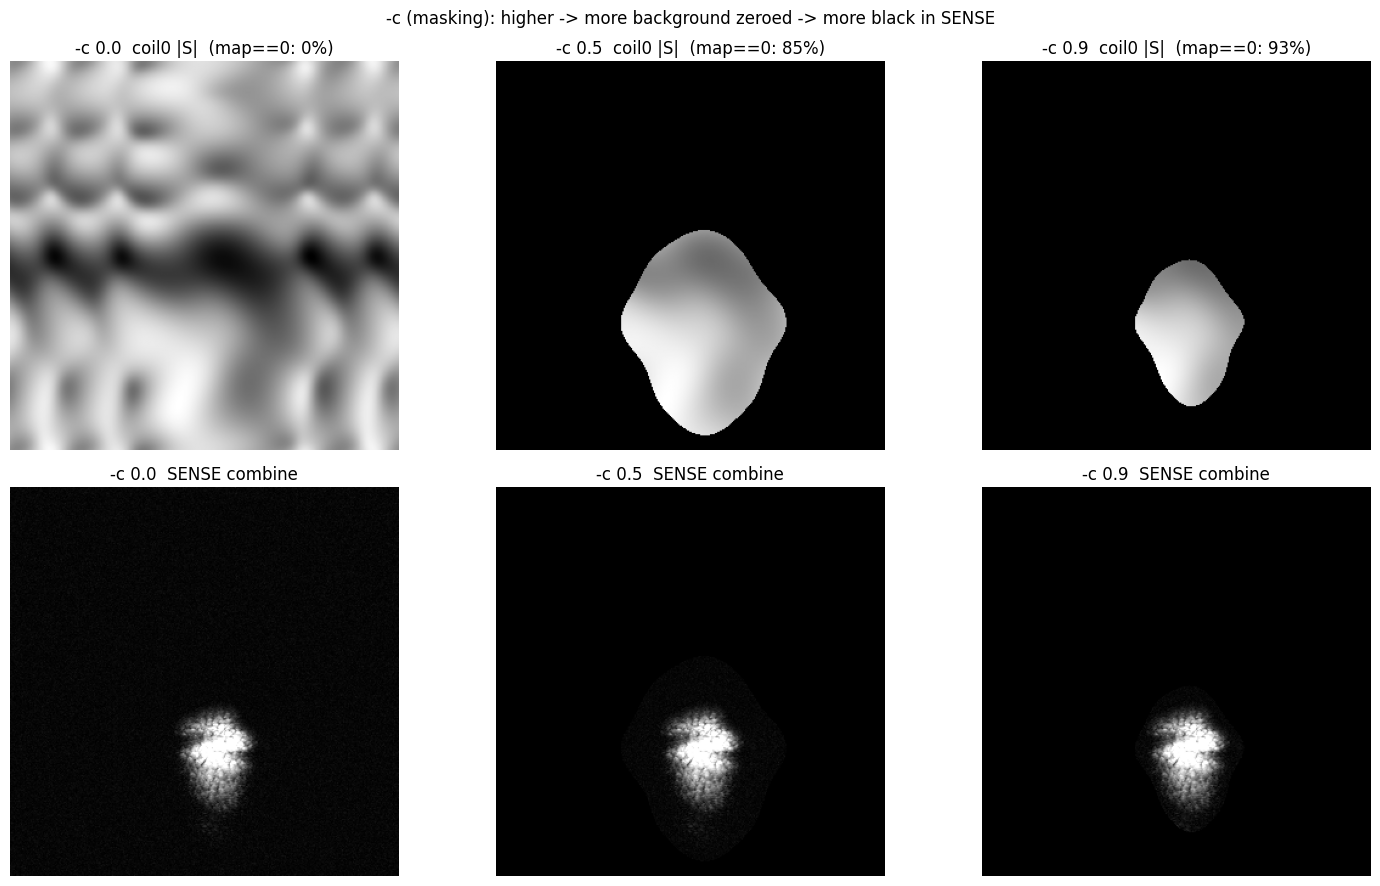

우리 MakeDataset 기본은 -c 없이(BART 기본 마스킹) -> 물체 바깥이 0 -> SENSE에 검은 영역


In [6]:
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
for j, c in enumerate([0.0, 0.5, 0.9]):
    sm = bart(1, f'ecalib -d0 -m1 -r24 -c{c}', kb)
    m = np.asarray(sm).transpose(3,1,2,0).squeeze(-1)
    sense = np.abs(sense_combine_np(k, m))
    frac0 = (np.sqrt((np.abs(m)**2).sum(0)) < 0.05).mean()*100
    ax[0, j].imshow(np.abs(m[0]), cmap='gray'); ax[0, j].set_title(f'-c {c}  coil0 |S|  (map==0: {frac0:.0f}%)'); ax[0, j].axis('off')
    ax[1, j].imshow(sense, cmap='gray', vmax=0.6*sense.max()); ax[1, j].set_title(f'-c {c}  SENSE combine'); ax[1, j].axis('off')
plt.suptitle('-c (masking): higher -> more background zeroed -> more black in SENSE'); plt.tight_layout(); plt.show()
print('우리 MakeDataset 기본은 -c 없이(BART 기본 마스킹) -> 물체 바깥이 0 -> SENSE에 검은 영역')

## 4. `-m` 맵 개수 (soft-SENSE)

`-m 2`면 픽셀마다 감도맵 2세트를 준다(FOV 접힘/신호가 두 영역에서 올 때 대비). 보통은 `-m 1`.

Done.


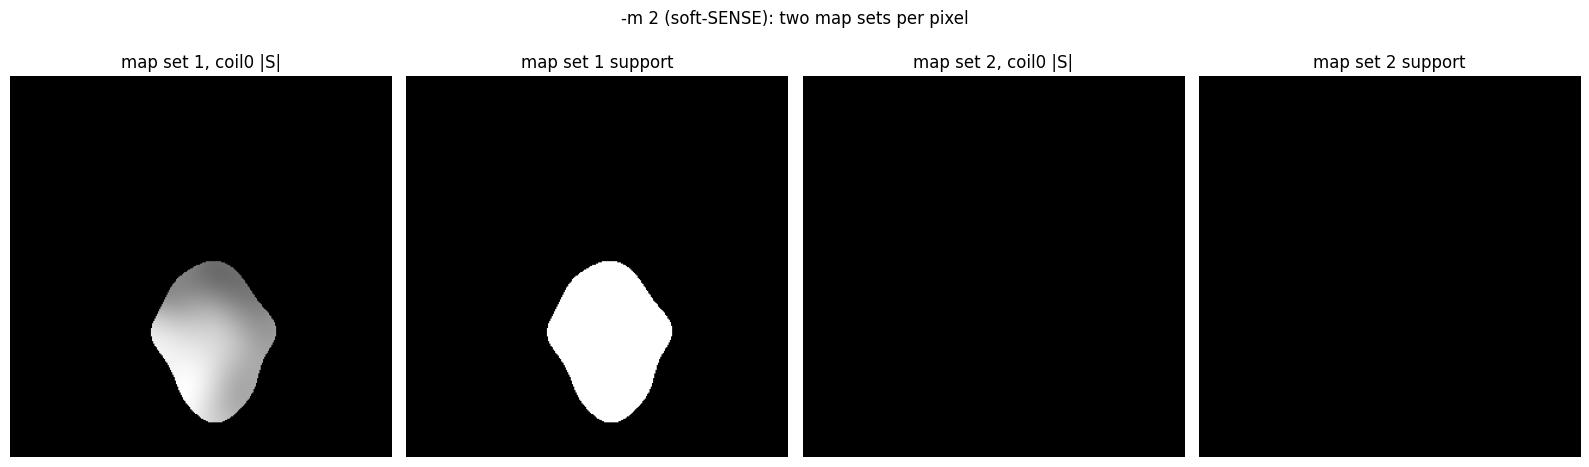

In [7]:
sm2 = bart(1, 'ecalib -d0 -m2 -r24', kb)                 # (1,H,W,C,2)
m2 = np.asarray(sm2)[0].transpose(2,0,1,3)               # (C,H,W,2)
fig, ax = plt.subplots(1, 4, figsize=(16, 5))
for s in range(2):
    ax[2*s].imshow(np.abs(m2[0,:,:,s]), cmap='gray'); ax[2*s].set_title(f'map set {s+1}, coil0 |S|'); ax[2*s].axis('off')
    ax[2*s+1].imshow(np.sqrt((np.abs(m2[:,:,:,s])**2).sum(0)), cmap='gray'); ax[2*s+1].set_title(f'map set {s+1} support'); ax[2*s+1].axis('off')
plt.suptitle('-m 2 (soft-SENSE): two map sets per pixel'); plt.tight_layout(); plt.show()

## 5. 우리 `MakeDataset.py`가 쓰는 호출 — 정리

```python
ks   = kspace_slice.transpose(1, 2, 0)[None]   # (1, H, W, C)  coil last
smap = bart(1, 'ecalib -d0 -m1 -r24', ks)      # (1, H, W, C, 1)
sens = smap.transpose(3, 1, 2, 0).squeeze(-1)  # (C, H, W)
```
- **layout**: BART는 (x,y,z,coil) → coil을 마지막 축으로, 앞에 singleton(z) 추가
- **`-d0`** debug off, **`-m1`** 맵 1개, **`-r24`** ACS 24
- crop된 320×320 k-space에서 호출 (감도맵도 320×320)

Done.
espirit_sens_maps -> (15, 320, 320) complex64
Done.
identical to manual ecalib call: True


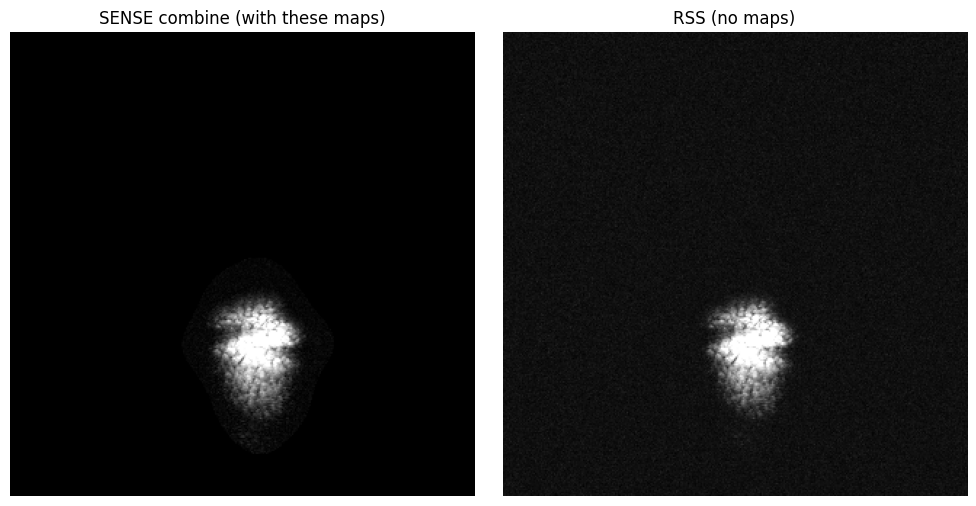

In [8]:
# verify: helper matches the manual call
sens_helper = espirit_sens_maps(k)                       # MakeDataset.espirit_sens_maps
print('espirit_sens_maps ->', sens_helper.shape, sens_helper.dtype)
manual = np.asarray(bart(1,'ecalib -d0 -m1 -r24', kb)).transpose(3,1,2,0).squeeze(-1)
print('identical to manual ecalib call:', np.allclose(sens_helper, manual))
# final SENSE combine + RSS for reference
fig, ax = plt.subplots(1,2,figsize=(10,5))
sense=np.abs(sense_combine_np(k,sens_helper))
ax[0].imshow(sense,cmap='gray',vmax=0.6*sense.max()); ax[0].set_title('SENSE combine (with these maps)'); ax[0].axis('off')
ax[1].imshow(rss_np(k),cmap='gray',vmax=0.6*rss_np(k).max()); ax[1].set_title('RSS (no maps)'); ax[1].axis('off')
plt.tight_layout(); plt.show()